In [4]:
#MNIST = Modified National Institute of Standards and Technology
#Is dataset me handwritten digits ki images hoti hain
#0 1 2 3 4 5 6 7 8 9

# TensorFlow ke Keras module se MNIST dataset ko import kar rahe hain
#
# MNIST ek famous handwritten digit image dataset hai
# Is dataset me 0 se 9 tak handwritten digits ki images present hoti hain
#
# MNIST ka use mainly Image Classification aur
# Neural Network / CNN ko samajhne ke liye kiya jata hai

from tensorflow.keras.datasets import mnist

In [5]:
# MNIST dataset ko load kar rahe hain
# Dataset already Training aur Testing data me divided hota hai
#
# x_train, x_test -> Handwritten digit images
# y_train, y_test -> Images ke actual labels (0-9)
#
# Training data -> Model ko train karne ke liye
# Testing data  -> Model ki final performance check karne ke liye

(x_train, y_train), (x_test, y_test) = mnist.load_data()

#MNIST Dataset      ↓
#┌───────────────┬───────────────┐
#│ Training Data │ Testing Data  │
#├───────────────┼───────────────┤
#│ x_train       │ x_test        │
#│ Images        │ Images        │
#│               │               │
#│ y_train       │ y_test        │
#│ Labels        │ Labels        │
#└───────────────┴───────────────┘

In [6]:
# x_train me total kitni training images hain, unki count check kar rahe hain
len(x_train)

60000

In [7]:
# Training aur Testing data ka shape check kar rahe hain
# Shape se total images aur har image ki dimensions pata chalti hain
print("x_train Shape:", x_train.shape)  # (60000, 28, 28)
print("y_train Shape:", y_train.shape)  # (60000,)

#(60000, 28, 28)
#    ↓     ↓   ↓
# Images  H   W

#x_train
#   │
#   ├── Image 0 → 28 × 28
#   ├── Image 1 → 28 × 28
#   ├── Image 2 → 28 × 28
#   ├── Image 3 → 28 × 28
#   │
#   └── ... Total 60,000 images

print("x_test Shape:", x_test.shape)    # (10000, 28, 28)
print("y_test Shape:", y_test.shape)    # (10000,)

#x_train = 60,000 training images
#x_test  = 10,000 testing images

#Each Image = 28 × 28 pixels
#y_train / y_test = Actual digit labels (0-9)

x_train Shape: (60000, 28, 28)
y_train Shape: (60000,)
x_test Shape: (10000, 28, 28)
y_test Shape: (10000,)


In [8]:
# Training images ka datatype check kar rahe hain
# MNIST images generally uint8 datatype me store hoti hain
x_train.dtype

#uint8 ka matlab unsigned 8-bit integer hota hai. Isme values ki range 0 se 255 hoti hai.
#MNIST me ye values pixel intensity represent karti hain:

#0   -> Black
#255 -> White
#Beech ki values -> Gray shades

dtype('uint8')

In [9]:
# x_train ki first image ko access kar rahe hain
# Image computer ke andar 28x28 pixel values ki matrix ke form me stored hoti hai
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [10]:
# Training dataset ki first image ka shape check kar rahe hain
# (28, 28) -> Image ki height 28 aur width 28 pixels hai
x_train[0].shape

(28, 28)

In [11]:
# First training image ka actual label / correct answer check kar rahe hain
# Ye batata hai ki x_train[0] wali image me actual digit kya hai
y_train[0]

#x_train[0] -> First digit ki image
#y_train[0] -> Us image ka actual label / answer

np.uint8(5)

In [12]:
# Training dataset ki first image ko display kar rahe hain
# cmap='gray' image ko grayscale format me show karta hai
plt.imshow(x_train[0], cmap='gray')

# Image ke around axis values ko hide kar rahe hain
plt.axis('off')

# Final image ko display kar rahe hain
plt.show()

NameError: name 'plt' is not defined

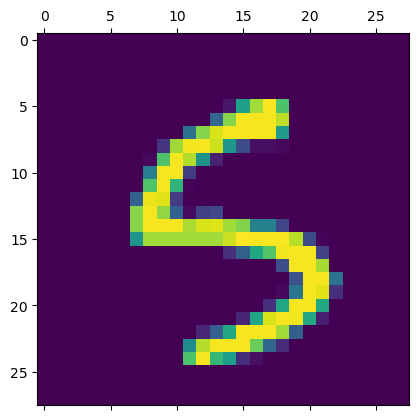

In [13]:
# Images ko display karne ke liye matplotlib.pyplot ko import kar rahe hain
import matplotlib.pyplot as plt

# Training dataset ki index 15000 wali image ko display kar rahe hain
# matshow() matrix/pixel values ko image ke form me show karta hai
plt.matshow(x_train[15000])

# Final image ko display kar rahe hain
plt.show()

In [14]:
# Training images me present minimum pixel value check kar rahe hain
x_train.min()

np.uint8(0)

In [15]:
# Training images me present maximum pixel value check kar rahe hain
x_train.max()

#0   -> Black
#255 -> White
#1-254 -> Different gray shades

np.uint8(255)

In [16]:
# TensorFlow se Keras import kar rahe hain
# Keras ka use Neural Network model banane aur train karne ke liye hota hai
from tensorflow import keras

# NumPy numerical operations aur arrays ke liye use hoti hai
import numpy as np


# -------------------- DATA NORMALIZATION --------------------

# MNIST images ki pixel values 0 se 255 ke beech hoti hain
# Neural Network small range ki values par better train hota hai

# Pixel values ko 255 se divide karke 0 se 1 range me convert kar rahe hain
# Example: 0 -> 0.0, 255 -> 1.0
# Is process ko Normalization kehte hain
x_train = x_train / 255.0

# Test data ko bhi same 0-1 range me normalize kar rahe hain
# Training aur testing data ka scale same hona chahiye
x_test = x_test / 255.0


# -------------------- FLATTENING IMAGES --------------------

# MNIST ki har image ka shape 28x28 hota hai
# Matlab har image ek 2D matrix ke form me stored hai

# Dense Neural Network ko 1D input dene ke liye
# 28x28 image ko 784 pixel values ki single array me convert kar rahe hain

# 28 * 28 = 784

# Before: (60000, 28, 28)
# After : (60000, 784)
x_train_flattened = x_train.reshape(len(x_train), 28 * 28)

# Same flattening test images par bhi apply kar rahe hain
# Before: (10000, 28, 28)
# After : (10000, 784)
x_test_flattened = x_test.reshape(len(x_test), 28 * 28)


# Flattened training data ka shape check kar rahe hain
# Expected output: (60000, 784)
#
# 60000 -> Total training images
# 784   -> Har image ke total pixel values
x_train_flattened.shape

(60000, 784)

In [17]:
from tensorflow import keras
# Sequential model bana rahe hain jisme layers ek ke baad ek execute hoti hain
model = keras.Sequential([
    
    # Dense output layer bana rahe hain with 10 neurons
    # 10 neurons digits 0 se 9 ko represent karte hain
    # input_shape=(784,) kyunki har 28x28 image ko 784 pixels me flatten kiya hai
    # sigmoid activation neuron ke output ko 0 se 1 ke beech convert karta hai
    keras.layers.Dense(10, input_shape=(784,), activation='sigmoid')
])


# Model ko training ke liye configure kar rahe hain
model.compile(
    
    # Adam optimizer weights ko update karke loss kam karta hai
    optimizer='adam',
    
    # Multi-class classification ke liye loss function
    # sparse use kiya kyunki y_train me labels direct numbers hain: 0, 1, 2...9
    loss='sparse_categorical_crossentropy',
    
    # Training ke time model ki accuracy bhi check karenge
    metrics=['accuracy']
)


# Model ko training data par 5 epochs tak train kar rahe hain
# 1 epoch = model poore training data ko ek baar dekhta hai
model.fit(x_train_flattened, y_train, epochs=5)

C:\Users\Prateek Verma\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8787 - loss: 0.4676
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9157 - loss: 0.3041
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9211 - loss: 0.2834
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9238 - loss: 0.2737
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9254 - loss: 0.2666


In [18]:
# Test data se sabhi digits ki prediction kar rahe hain
# Model har image ke liye 10 output values/probabilities dega
y_predict = model.predict(x_test_flattened)

# First test image ki prediction values check kar rahe hain
# Ye 10 values digits 0 se 9 ko represent karti hain
y_predict[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 834us/step


array([2.98965462e-02, 3.48062372e-07, 6.21019714e-02, 9.67132688e-01,
       3.12050665e-03, 1.28814012e-01, 1.97564418e-06, 9.99829471e-01,
       1.17629975e-01, 7.38807797e-01], dtype=float32)

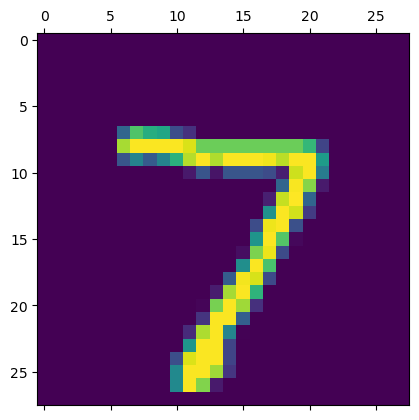

In [19]:
plt.matshow(x_test[0])

In [20]:
import numpy as np
# Highest probability wali class ka index nikal rahe hain
# Ye index hi predicted digit hai
np.argmax(y_predict[0])

np.int64(7)

In [21]:
# Model ne har test image ke liye 10 class probabilities predict ki hain
# np.argmax() har prediction me sabse highest probability ka index return karta hai
# Ye index hi model ka predicted digit (0-9) hota hai

y_predict_labels = [np.argmax(i) for i in y_predict]

# Pehli 10 predicted labels dekh rahe hain
y_predict_labels[:10]

[np.int64(7),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(4),
 np.int64(9),
 np.int64(6),
 np.int64(9)]

In [22]:
# TensorFlow library ko tf naam se import kar rahe hain
# TensorFlow ke andar confusion_matrix() function available hai
import tensorflow as tf
# Confusion Matrix create kar rahe hain

# labels      -> Actual (True) values jo y_test me hain
# predictions -> Model dwara predict kiye gaye labels

# Har row actual class ko represent karti hai
# Har column predicted class ko represent karta hai
cm = tf.math.confusion_matrix(
    labels=y_test,
    predictions=y_predict_labels
)
# Confusion Matrix display kar rahe hain
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 961,    0,    2,    2,    0,    5,    7,    2,    1,    0],
       [   0, 1117,    2,    2,    0,    1,    4,    2,    7,    0],
       [   6,   10,  924,   15,    7,    3,   13,   10,   39,    5],
       [   5,    0,   20,  913,    1,   25,    3,   11,   23,    9],
       [   1,    1,    4,    2,  912,    0,   13,    4,   10,   35],
       [  10,    3,    5,   25,   11,  778,   19,    4,   29,    8],
       [  12,    3,    4,    1,    7,   10,  918,    2,    1,    0],
       [   1,    8,   22,    7,    6,    0,    0,  941,    3,   40],
       [   6,    9,    8,   15,    9,   20,   10,   11,  875,   11],
       [  11,    7,    1,    8,   24,    6,    0,   19,    7,  926]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

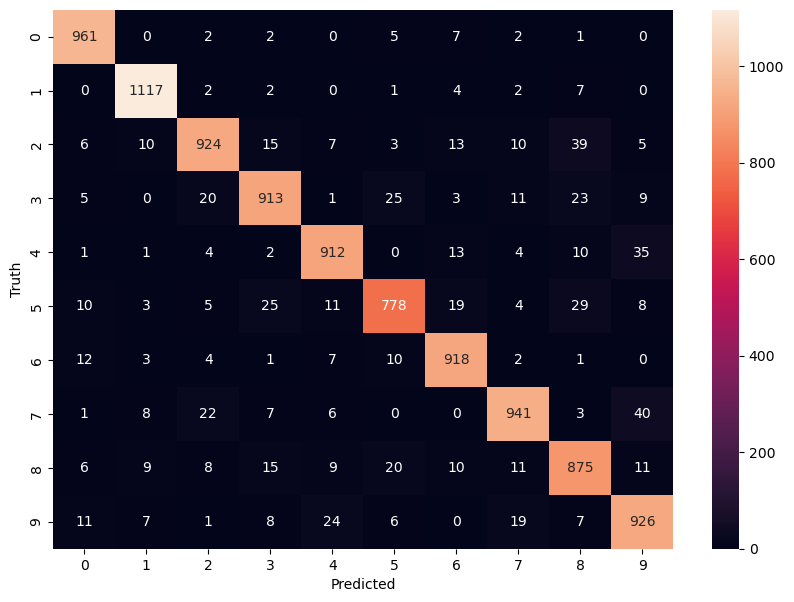

In [23]:
# Seaborn library ko import kar rahe hain
# Heatmap banane ke liye use hoti hai
import seaborn as sns

# Figure ka size set kar rahe hain
plt.figure(figsize=(10,7))

# Confusion Matrix ko heatmap ke form me display kar rahe hain
# annot=True -> Har cell ki value show karega
# fmt='d' -> Values integer format me display hongi
sns.heatmap(cm, annot=True, fmt='d')

# X-axis model ki predicted labels ko represent karti hai
plt.xlabel('Predicted')

# Y-axis actual (true) labels ko represent karti hai
plt.ylabel('Truth')

In [28]:
#Training on another model with more layers

from tensorflow import keras

model= keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9240 - loss: 0.2700
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9641 - loss: 0.1218
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9744 - loss: 0.0852
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9803 - loss: 0.0653
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9850 - loss: 0.0501
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9876 - loss: 0.0412
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9898 - loss: 0.0335
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9912 - loss: 0.0279
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9927 - loss: 0.0231
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9938 - loss: 0.0192


In [32]:
# Test data se sabhi digits ki prediction kar rahe hain
# Model har image ke liye 10 output values/probabilities dega
y_predict = model.predict(x_test)

# First test image ki prediction values check kar rahe hain
# Ye 10 values digits 0 se 9 ko represent karti hain
y_predict[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step


array([3.1083968e-02, 1.2063156e-03, 1.0406156e-01, 6.5692329e-01,
       1.5860427e-07, 7.3202886e-05, 8.2500534e-08, 9.9999887e-01,
       4.0090472e-02, 5.2514911e-01], dtype=float32)

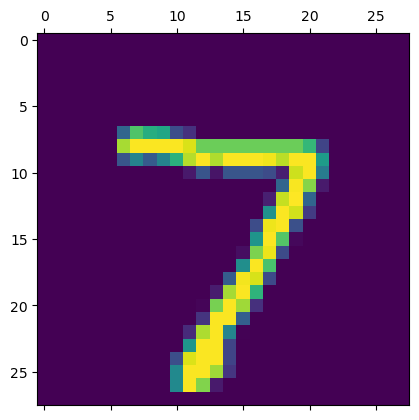

In [33]:
plt.matshow(x_test[0])

In [34]:
import numpy as np
# Highest probability wali class ka index nikal rahe hain
# Ye index hi predicted digit hai
np.argmax(y_predict[0])

np.int64(7)

Text(95.72222222222221, 0.5, 'Truth')

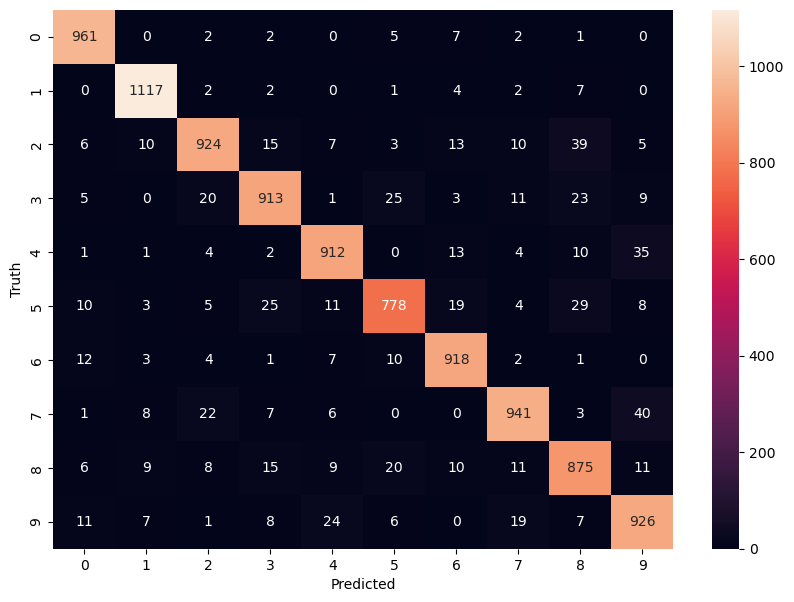

In [35]:
# Seaborn library ko import kar rahe hain
# Heatmap banane ke liye use hoti hai
import seaborn as sns

# Figure ka size set kar rahe hain
plt.figure(figsize=(10,7))

# Confusion Matrix ko heatmap ke form me display kar rahe hain
# annot=True -> Har cell ki value show karega
# fmt='d' -> Values integer format me display hongi
sns.heatmap(cm, annot=True, fmt='d')

# X-axis model ki predicted labels ko represent karti hai
plt.xlabel('Predicted')

# Y-axis actual (true) labels ko represent karti hai
plt.ylabel('Truth')